In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
pd.options.display.max_columns=None
import warnings


In [2]:
test = pd.read_csv('/kaggle/input/hms-harmful-brain-activity-classification/test.csv')
test.head()

,spectrogram_id,eeg_id,patient_id
0,853520,3911565283,6885


In [3]:
train = pd.read_csv('/kaggle/input/hms-harmful-brain-activity-classification/train.csv')
train.head()

,eeg_id,eeg_sub_id,eeg_label_offset_seconds,spectrogram_id,spectrogram_sub_id,spectrogram_label_offset_seconds,label_id,patient_id,expert_consensus,seizure_vote,lpd_vote,gpd_vote,lrda_vote,grda_vote,other_vote
0,1628180742,0,0.0,353733,0,0.0,127492639,42516,Seizure,3,0,0,0,0,0
1,1628180742,1,6.0,353733,1,6.0,3887563113,42516,Seizure,3,0,0,0,0,0
2,1628180742,2,8.0,353733,2,8.0,1142670488,42516,Seizure,3,0,0,0,0,0
3,1628180742,3,18.0,353733,3,18.0,2718991173,42516,Seizure,3,0,0,0,0,0
4,1628180742,4,24.0,353733,4,24.0,3080632009,42516,Seizure,3,0,0,0,0,0


In [4]:
combined = pd.concat([train,test])
combined.head()

,eeg_id,eeg_sub_id,eeg_label_offset_seconds,spectrogram_id,spectrogram_sub_id,spectrogram_label_offset_seconds,label_id,patient_id,expert_consensus,seizure_vote,lpd_vote,gpd_vote,lrda_vote,grda_vote,other_vote
0,1628180742,0.0,0.0,353733,0.0,0.0,1.274926e+08,42516,Seizure,3.0,0.0,0.0,0.0,0.0,0.0
1,1628180742,1.0,6.0,353733,1.0,6.0,3.887563e+09,42516,Seizure,3.0,0.0,0.0,0.0,0.0,0.0
2,1628180742,2.0,8.0,353733,2.0,8.0,1.142670e+09,42516,Seizure,3.0,0.0,0.0,0.0,0.0,0.0
3,1628180742,3.0,18.0,353733,3.0,18.0,2.718991e+09,42516,Seizure,3.0,0.0,0.0,0.0,0.0,0.0
4,1628180742,4.0,24.0,353733,4.0,24.0,3.080632e+09,42516,Seizure,3.0,0.0,0.0,0.0,0.0,0.0


In [11]:
combined.info()

<class 'pandas.core.frame.DataFrame'>
Index: 106801 entries, 0 to 0
Data columns (total 15 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   eeg_id                            106801 non-null  int64  
 1   eeg_sub_id                        106800 non-null  float64
 2   eeg_label_offset_seconds          106800 non-null  float64
 3   spectrogram_id                    106801 non-null  int64  
 4   spectrogram_sub_id                106800 non-null  float64
 5   spectrogram_label_offset_seconds  106800 non-null  float64
 6   label_id                          106800 non-null  float64
 7   patient_id                        106801 non-null  int64  
 8   expert_consensus                  106800 non-null  object 
 9   seizure_vote                      106800 non-null  float64
 10  lpd_vote                          106800 non-null  float64
 11  gpd_vote                          106800 non-null  float64
 12

In [16]:
combined.dtypes

eeg_id                                int64
eeg_sub_id                          float64
eeg_label_offset_seconds            float64
spectrogram_id                        int64
spectrogram_sub_id                  float64
spectrogram_label_offset_seconds    float64
label_id                            float64
patient_id                            int64
expert_consensus                     object
seizure_vote                        float64
lpd_vote                            float64
gpd_vote                            float64
lrda_vote                           float64
grda_vote                           float64
other_vote                          float64
dtype: object

In [8]:
combined.isnull().sum()/len(combined*100)

eeg_id                              0.000000
eeg_sub_id                          0.000009
eeg_label_offset_seconds            0.000009
spectrogram_id                      0.000000
spectrogram_sub_id                  0.000009
spectrogram_label_offset_seconds    0.000009
label_id                            0.000009
patient_id                          0.000000
expert_consensus                    0.000009
seizure_vote                        0.000009
lpd_vote                            0.000009
gpd_vote                            0.000009
lrda_vote                           0.000009
grda_vote                           0.000009
other_vote                          0.000009
dtype: float64

In [10]:
combined.columns

Index(['eeg_id', 'eeg_sub_id', 'eeg_label_offset_seconds', 'spectrogram_id',
       'spectrogram_sub_id', 'spectrogram_label_offset_seconds', 'label_id',
       'patient_id', 'expert_consensus', 'seizure_vote', 'lpd_vote',
       'gpd_vote', 'lrda_vote', 'grda_vote', 'other_vote'],
      dtype='object')

In [11]:
combined.shape

(106801, 15)

In [12]:
combined.describe().T

,count,mean,std,min,25%,50%,75%,max
eeg_id,106801.0,2.104404e+09,1.233377e+09,568657.0,1.026896e+09,2.071326e+09,3.172787e+09,4.294958e+09
eeg_sub_id,106800.0,2.628619e+01,6.975766e+01,0.0,1.000000e+00,5.000000e+00,1.600000e+01,7.420000e+02
eeg_label_offset_seconds,106800.0,1.188172e+02,3.145578e+02,0.0,6.000000e+00,2.600000e+01,8.200000e+01,3.372000e+03
spectrogram_id,106801.0,1.067252e+09,6.291530e+08,353733.0,5.238626e+08,1.057904e+09,1.623195e+09,2.147388e+09
spectrogram_sub_id,106800.0,4.373360e+01,1.042921e+02,0.0,2.000000e+00,8.000000e+00,2.900000e+01,1.021000e+03
spectrogram_label_offset_seconds,106800.0,5.204314e+02,1.449760e+03,0.0,1.200000e+01,6.200000e+01,3.940000e+02,1.763200e+04
label_id,106800.0,2.141415e+09,1.241670e+09,338.0,1.067419e+09,2.138332e+09,3.217816e+09,4.294934e+09
patient_id,106801.0,3.230419e+04,1.853827e+04,56.0,1.670700e+04,3.206800e+04,4.803600e+04,6.549400e+04
seizure_vote,106800.0,8.780243e-01,1.538873e+00,0.0,0.000000e+00,0.000000e+00,1.000000e+00,1.900000e+01
lpd_vote,106800.0,1.138783e+00,2.818845e+00,0.0,0.000000e+00,0.000000e+00,1.000000e+00,1.800000e+01


In [12]:
cat_cols = combined.select_dtypes (include='object')

In [13]:
for i in cat_cols:
    print(i)
    (combined[i].value_counts())
    print('_'*50)
    

expert_consensus
__________________________________________________


In [14]:
num_cols = combined.select_dtypes(include='number')

In [15]:
for i in num_cols:
    print(i)
    (combined[i].value_counts())
    print('_'*50)

eeg_id
__________________________________________________
eeg_sub_id
__________________________________________________
eeg_label_offset_seconds
__________________________________________________
spectrogram_id
__________________________________________________
spectrogram_sub_id
__________________________________________________
spectrogram_label_offset_seconds
__________________________________________________
label_id
__________________________________________________
patient_id
__________________________________________________
seizure_vote
__________________________________________________
lpd_vote
__________________________________________________
gpd_vote
__________________________________________________
lrda_vote
__________________________________________________
grda_vote
__________________________________________________
other_vote
__________________________________________________


In [16]:
num_cols

,eeg_id,eeg_sub_id,eeg_label_offset_seconds,spectrogram_id,spectrogram_sub_id,spectrogram_label_offset_seconds,label_id,patient_id,seizure_vote,lpd_vote,gpd_vote,lrda_vote,grda_vote,other_vote
0,1628180742,0.0,0.0,353733,0.0,0.0,1.274926e+08,42516,3.0,0.0,0.0,0.0,0.0,0.0
1,1628180742,1.0,6.0,353733,1.0,6.0,3.887563e+09,42516,3.0,0.0,0.0,0.0,0.0,0.0
2,1628180742,2.0,8.0,353733,2.0,8.0,1.142670e+09,42516,3.0,0.0,0.0,0.0,0.0,0.0
3,1628180742,3.0,18.0,353733,3.0,18.0,2.718991e+09,42516,3.0,0.0,0.0,0.0,0.0,0.0
4,1628180742,4.0,24.0,353733,4.0,24.0,3.080632e+09,42516,3.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106796,351917269,7.0,14.0,2147388374,7.0,14.0,2.908967e+08,10351,0.0,0.0,0.0,3.0,0.0,0.0
106797,351917269,8.0,16.0,2147388374,8.0,16.0,4.614355e+08,10351,0.0,0.0,0.0,3.0,0.0,0.0
106798,351917269,9.0,18.0,2147388374,9.0,18.0,3.786213e+09,10351,0.0,0.0,0.0,3.0,0.0,0.0
106799,351917269,10.0,20.0,2147388374,10.0,20.0,3.642716e+09,10351,0.0,0.0,0.0,3.0,0.0,0.0


/n


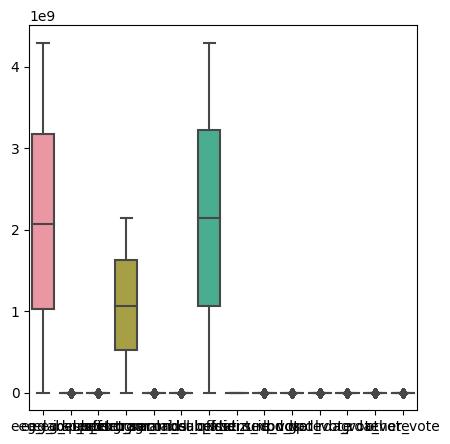

In [32]:
plt.figure(figsize=(5,5))
x =i
for i in cat_cols:
    sns.boxplot(data=combined)
    print('/n')
    plt.show()

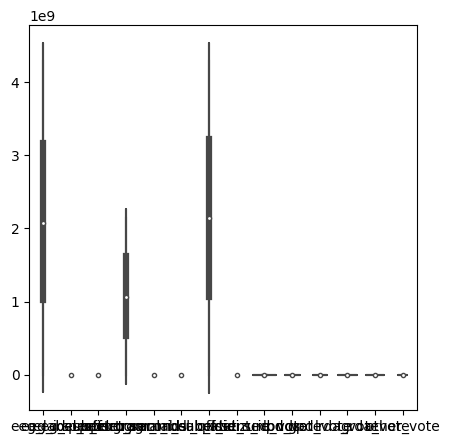

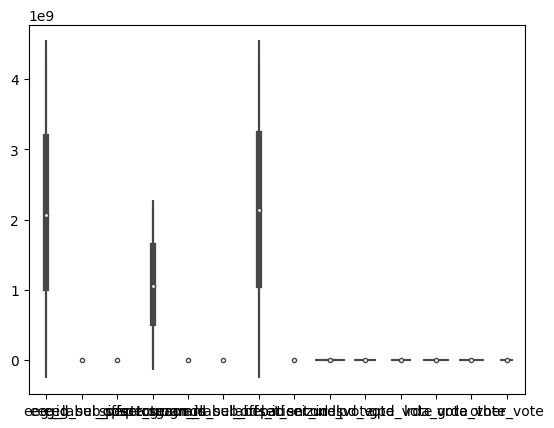

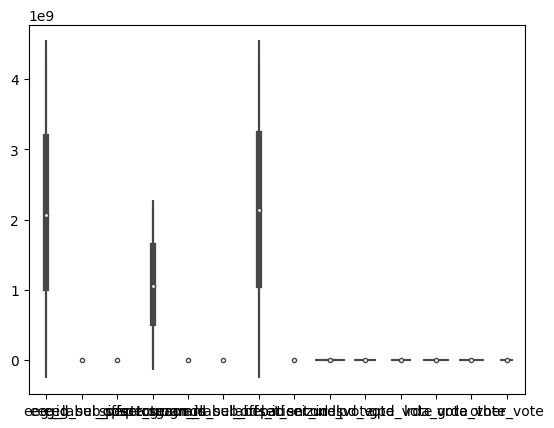

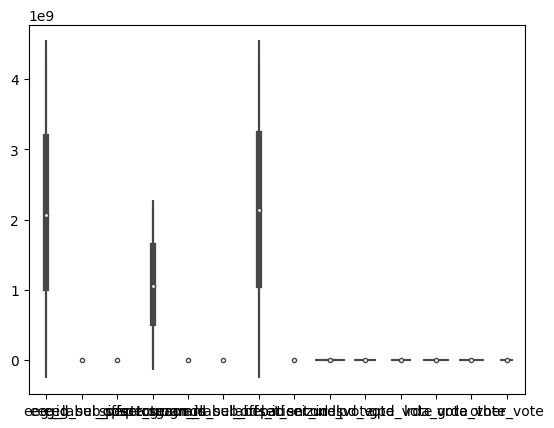

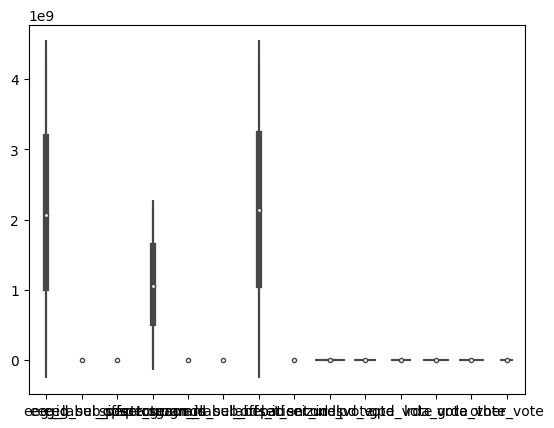

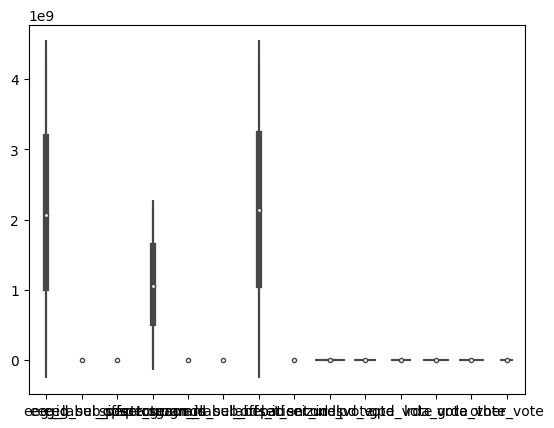

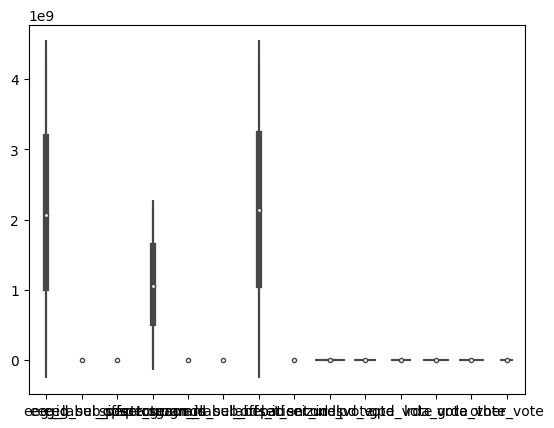

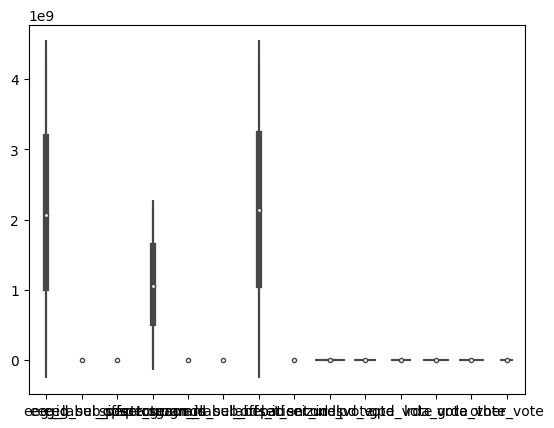

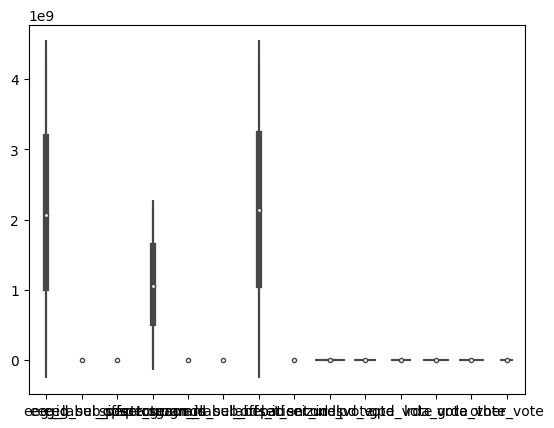

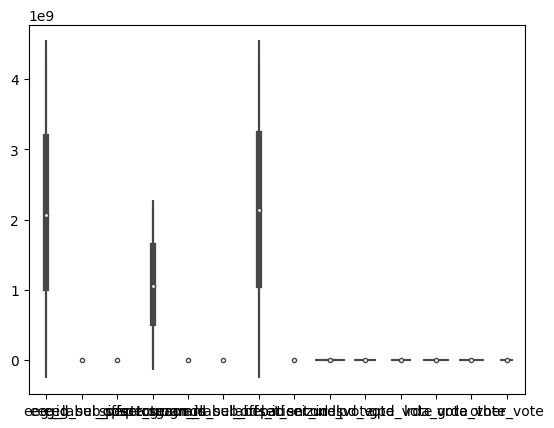

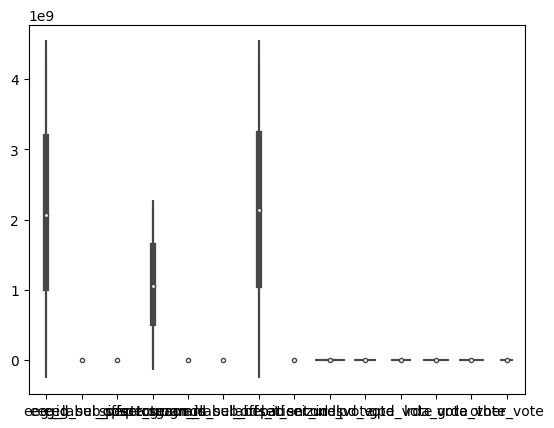

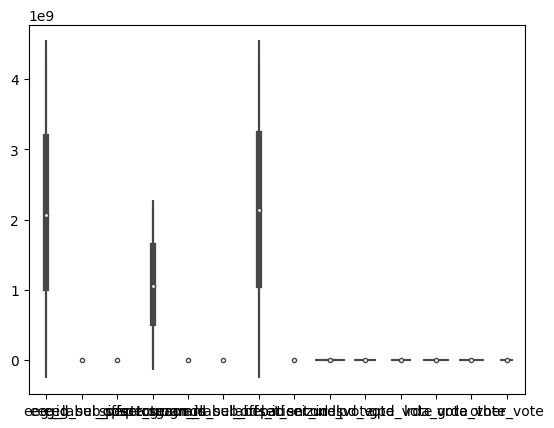

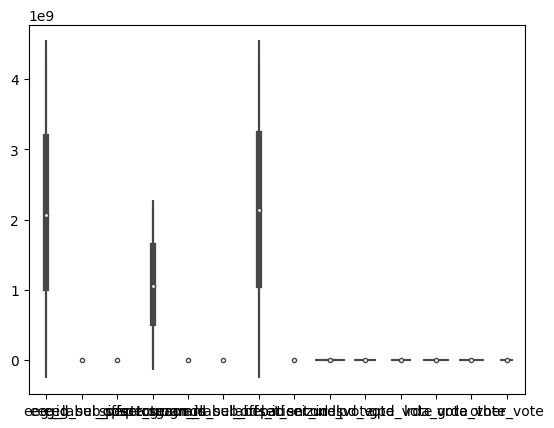

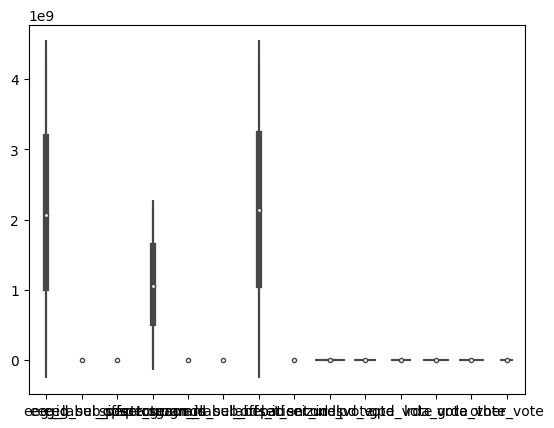

In [33]:
plt.figure(figsize=(5,5))
x=i
for i in num_cols:
    sns.violinplot(data=combined)
    print('\n')
    plt.show()

<Axes: >

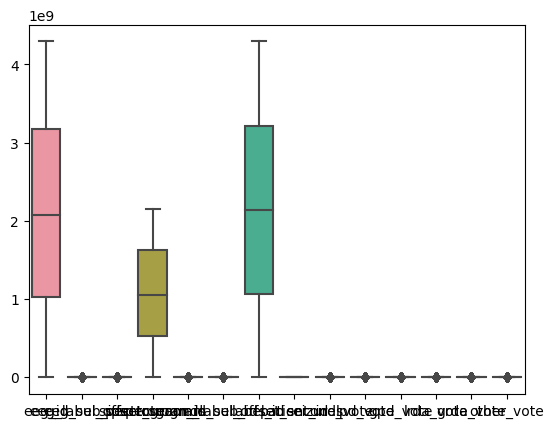

In [34]:
sns.boxplot(combined)

<Axes: >

/opt/conda/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/opt/conda/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


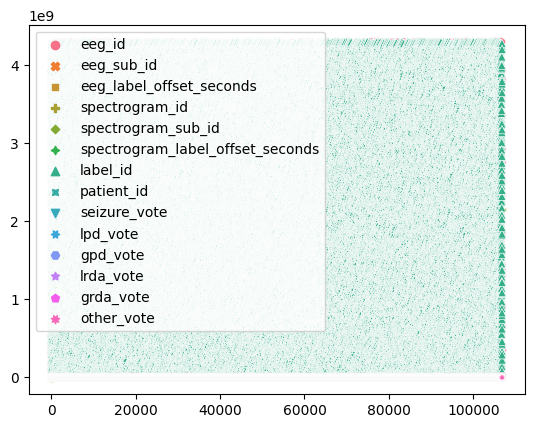

In [35]:
sns.scatterplot(combined)

<Axes: >

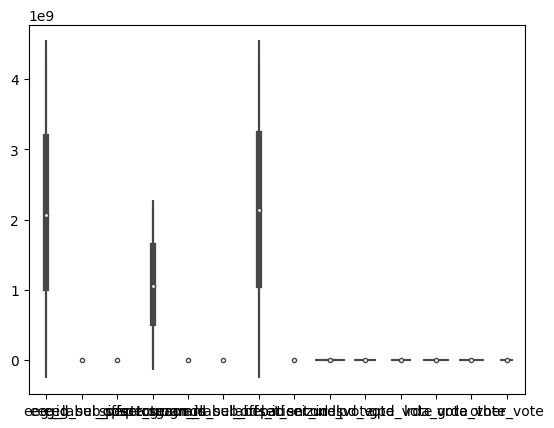

In [37]:
sns.violinplot(combined)

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

<Axes: ylabel='Density'>

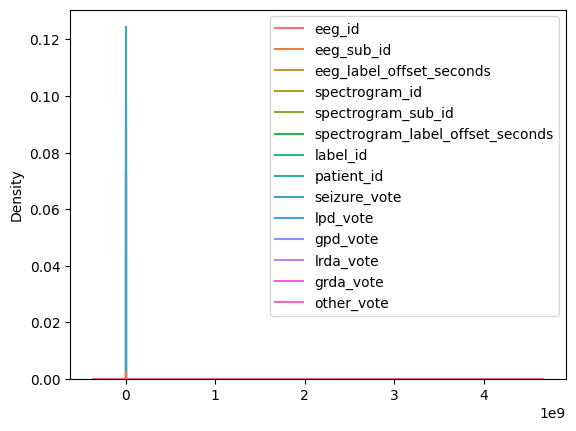

In [36]:
sns.kdeplot(combined)

<Axes: >

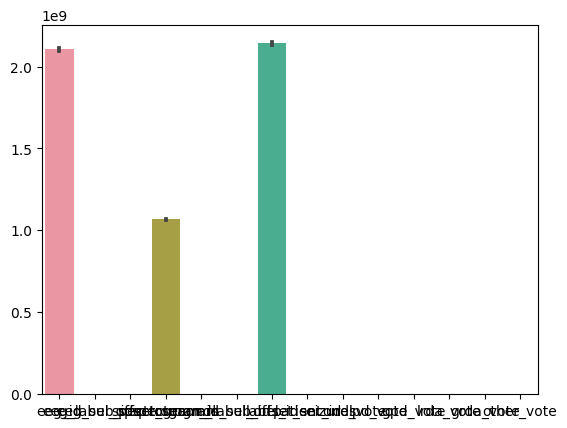

In [41]:
sns.barplot(combined)

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

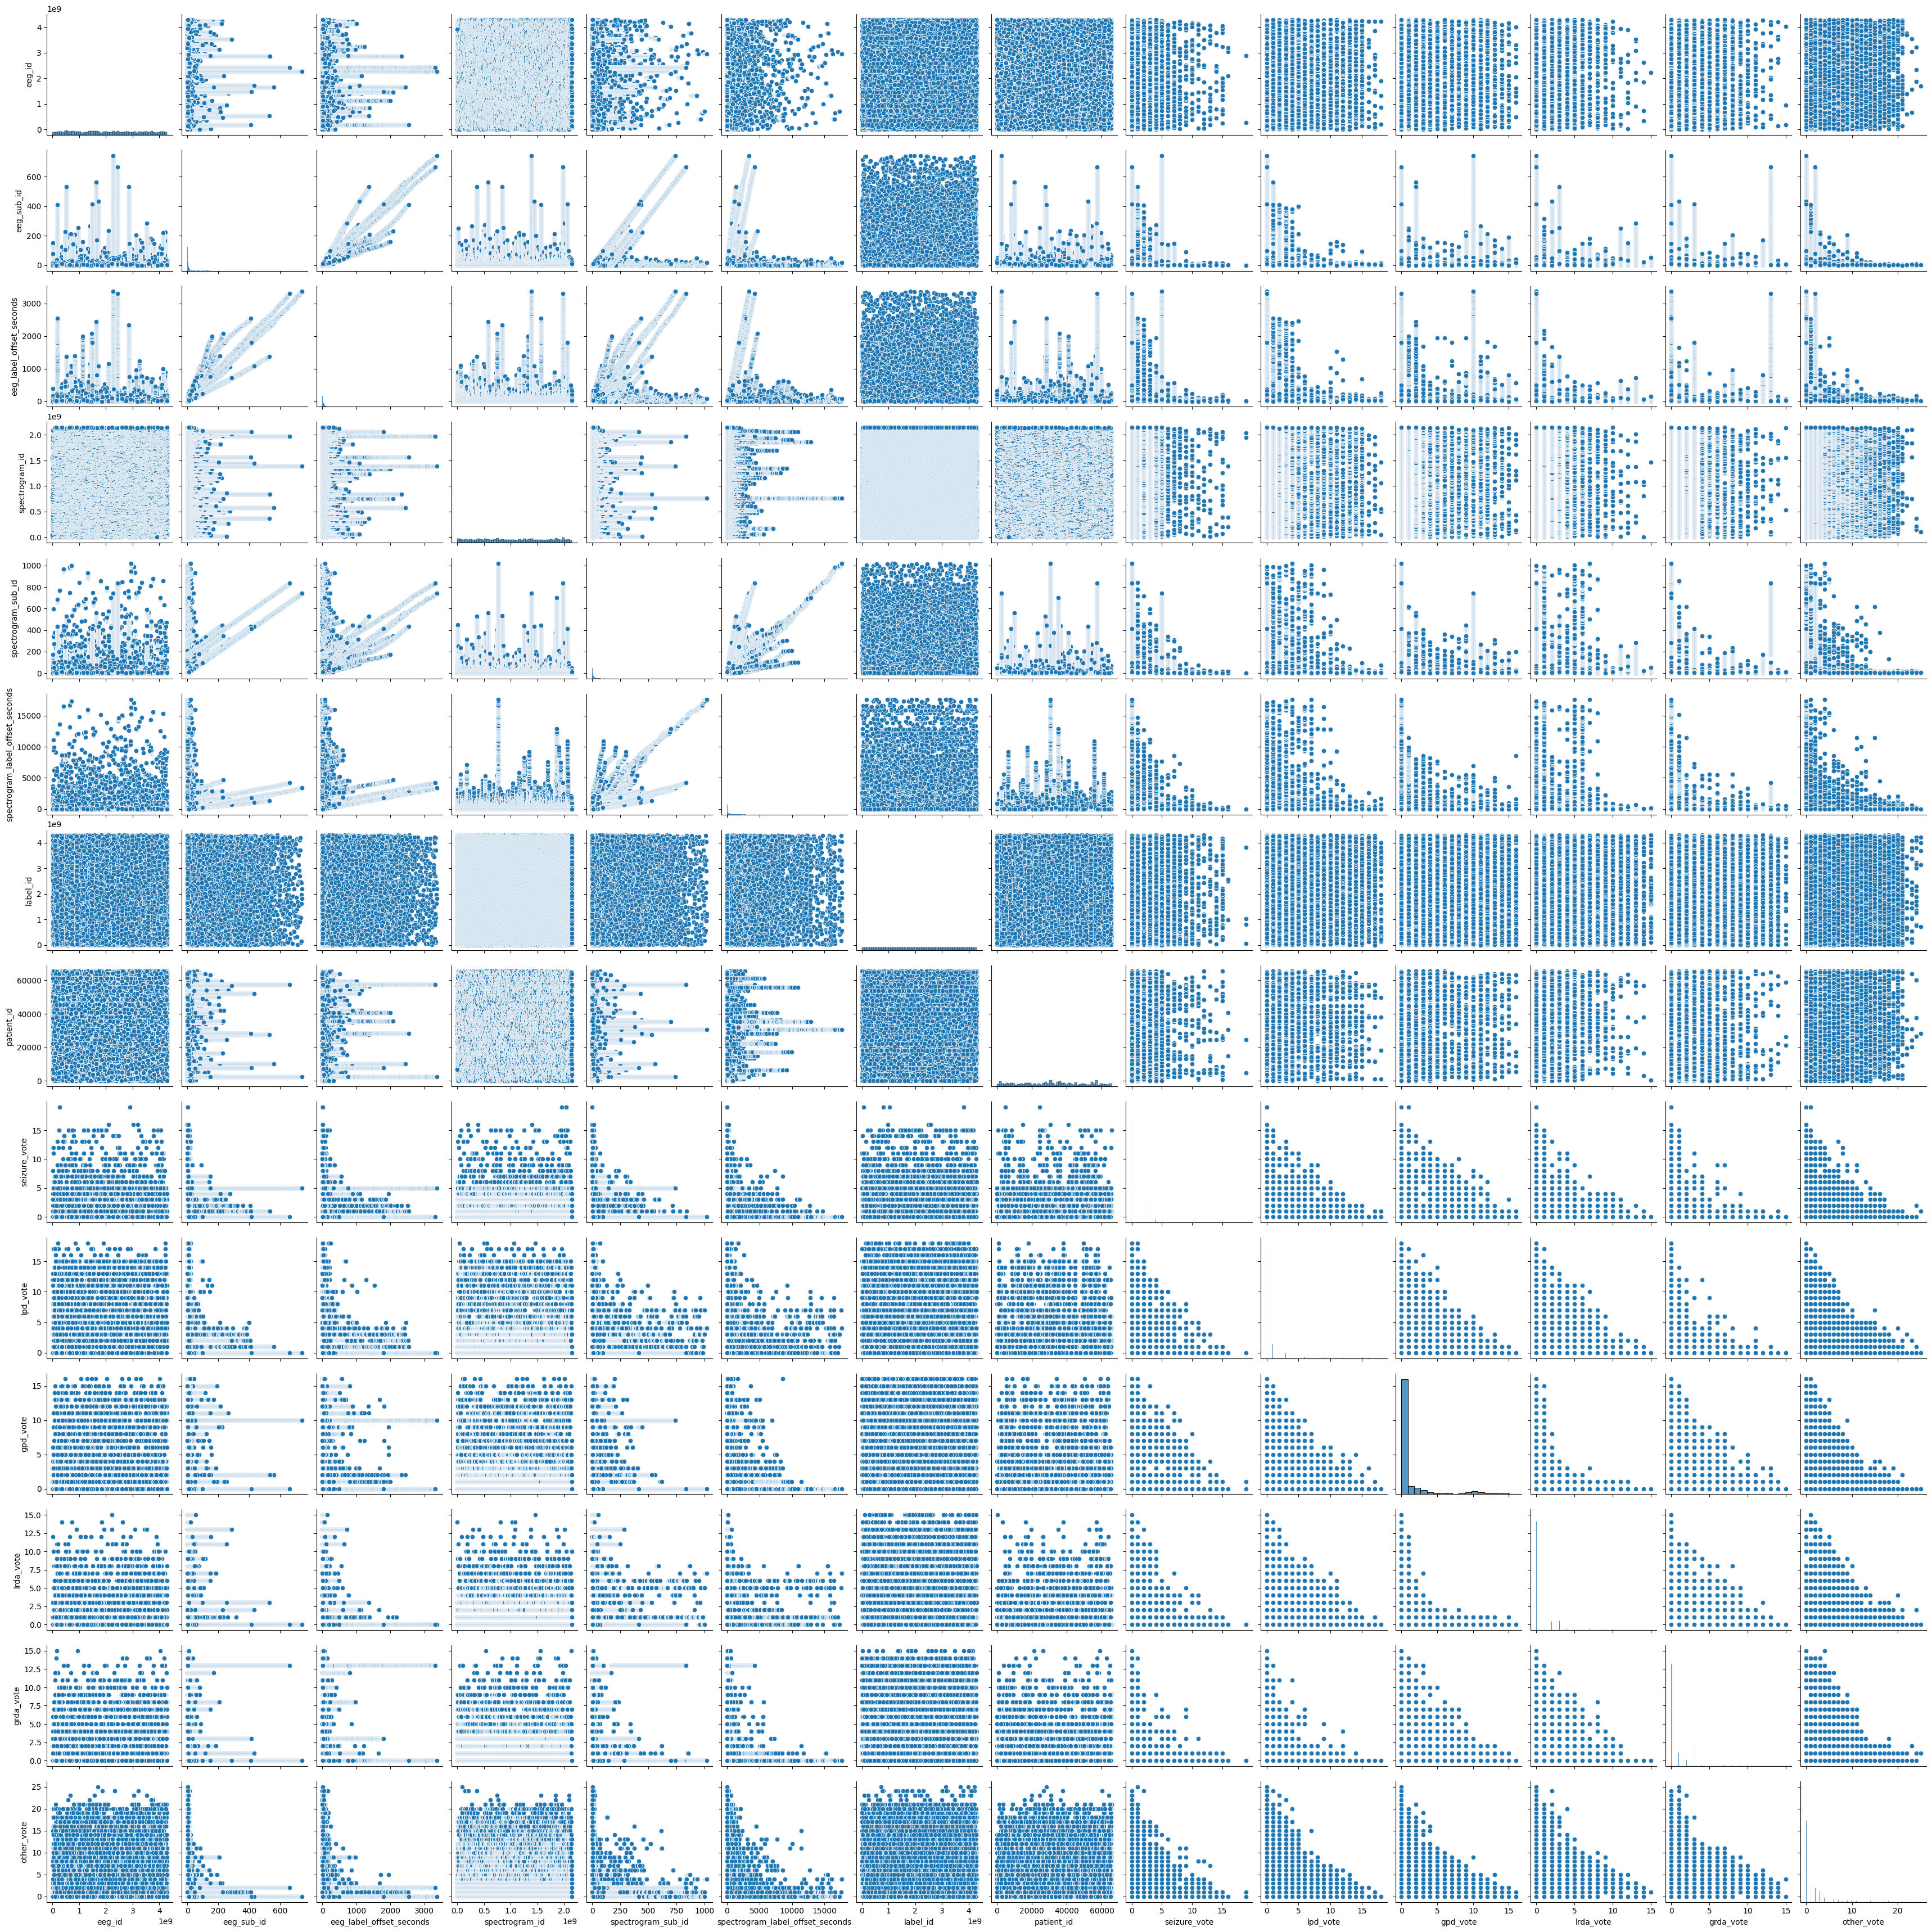

In [43]:
sns.pairplot(combined)

In [38]:
combined.skew

<bound method DataFrame.skew of             eeg_id  eeg_sub_id  eeg_label_offset_seconds  spectrogram_id  \
0       1628180742         0.0                       0.0          353733   
1       1628180742         1.0                       6.0          353733   
2       1628180742         2.0                       8.0          353733   
3       1628180742         3.0                      18.0          353733   
4       1628180742         4.0                      24.0          353733   
...            ...         ...                       ...             ...   
106796   351917269         7.0                      14.0      2147388374   
106797   351917269         8.0                      16.0      2147388374   
106798   351917269         9.0                      18.0      2147388374   
106799   351917269        10.0                      20.0      2147388374   
0       3911565283         NaN                       NaN          853520   

        spectrogram_sub_id  spectrogram_label_offset_se

In [39]:
combined.kurt

<bound method DataFrame.kurt of             eeg_id  eeg_sub_id  eeg_label_offset_seconds  spectrogram_id  \
0       1628180742         0.0                       0.0          353733   
1       1628180742         1.0                       6.0          353733   
2       1628180742         2.0                       8.0          353733   
3       1628180742         3.0                      18.0          353733   
4       1628180742         4.0                      24.0          353733   
...            ...         ...                       ...             ...   
106796   351917269         7.0                      14.0      2147388374   
106797   351917269         8.0                      16.0      2147388374   
106798   351917269         9.0                      18.0      2147388374   
106799   351917269        10.0                      20.0      2147388374   
0       3911565283         NaN                       NaN          853520   

        spectrogram_sub_id  spectrogram_label_offset_se

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13]),
 [Text(0, 0, 'eeg_id'),
  Text(1, 0, 'eeg_sub_id'),
  Text(2, 0, 'eeg_label_offset_seconds'),
  Text(3, 0, 'spectrogram_id'),
  Text(4, 0, 'spectrogram_sub_id'),
  Text(5, 0, 'spectrogram_label_offset_seconds'),
  Text(6, 0, 'label_id'),
  Text(7, 0, 'patient_id'),
  Text(8, 0, 'seizure_vote'),
  Text(9, 0, 'lpd_vote'),
  Text(10, 0, 'gpd_vote'),
  Text(11, 0, 'lrda_vote'),
  Text(12, 0, 'grda_vote'),
  Text(13, 0, 'other_vote')])

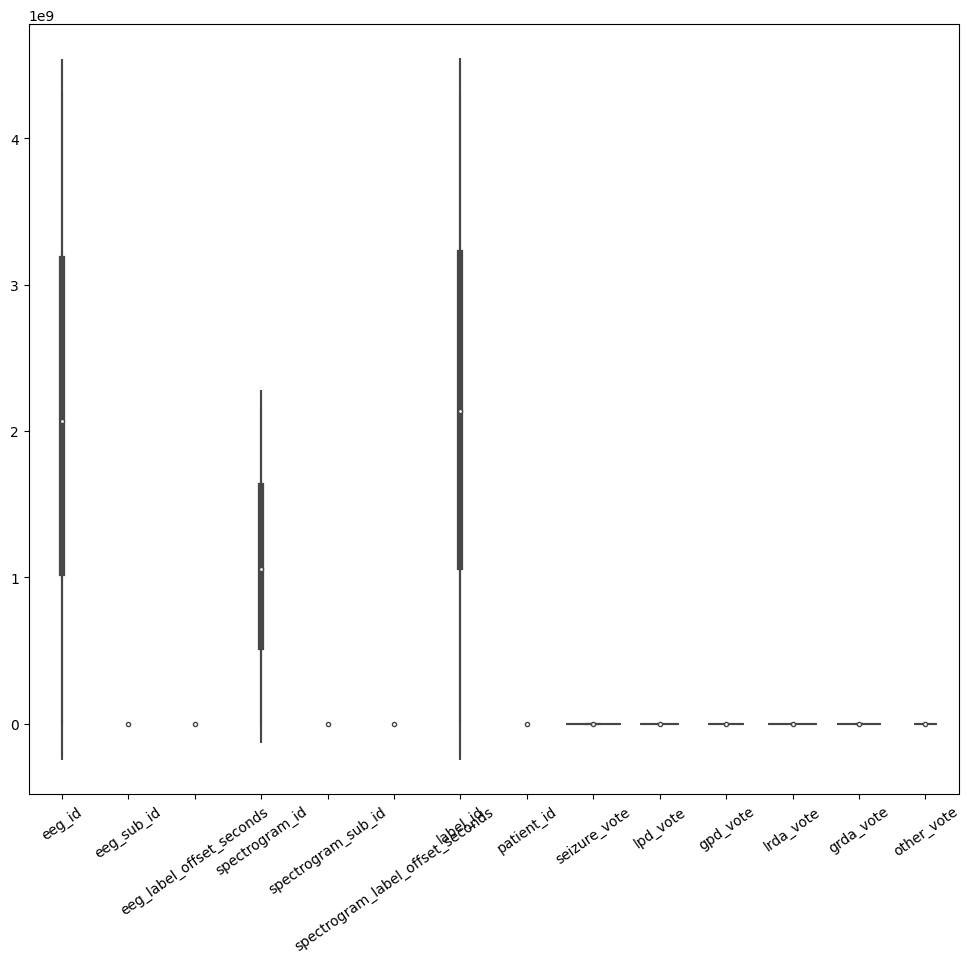

In [56]:
plt.figure(figsize=(12,10))
sns.violinplot(data=combined);
plt.xticks(rotation=35)

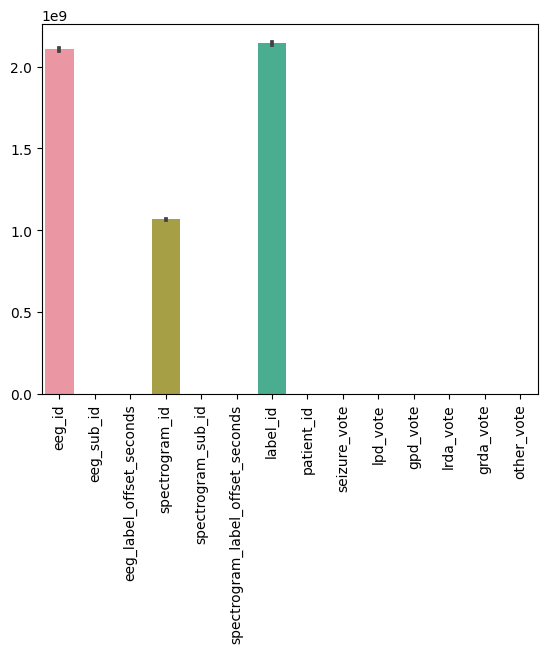

In [51]:
sns.barplot(data=combined)
plt.xticks(rotation=90);

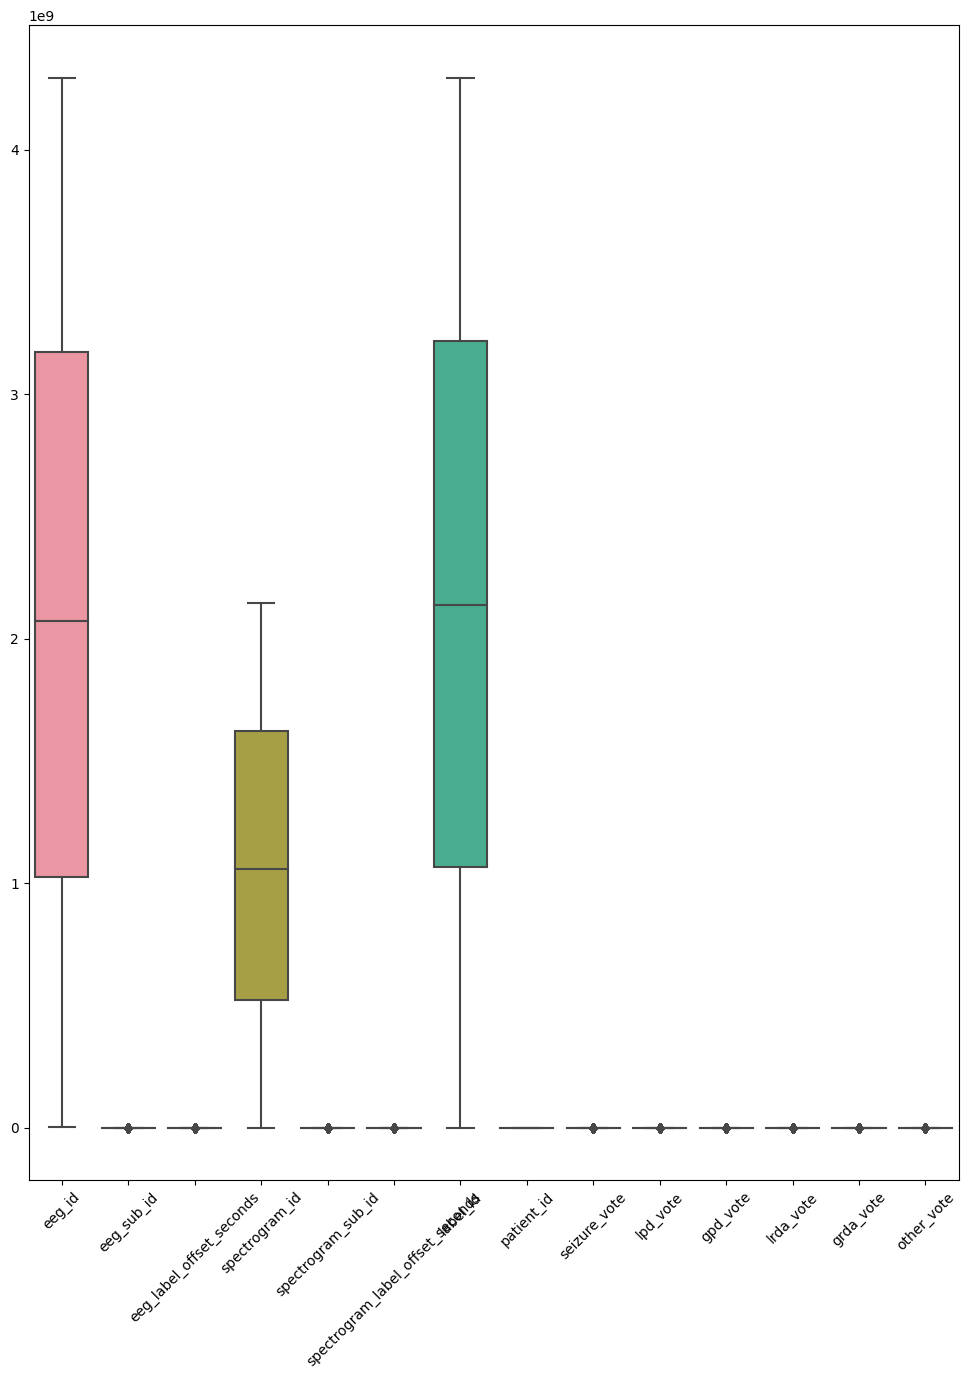

In [54]:
plt.figure(figsize=(12,15))
sns.boxplot(data=combined);
plt.xticks(rotation=45);

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import statsmodels
import statsmodels.api as sm 


In [61]:
combined.head()

,eeg_id,eeg_sub_id,eeg_label_offset_seconds,spectrogram_id,spectrogram_sub_id,spectrogram_label_offset_seconds,label_id,patient_id,expert_consensus,seizure_vote,lpd_vote,gpd_vote,lrda_vote,grda_vote,other_vote
0,1628180742,0.0,0.0,353733,0.0,0.0,1.274926e+08,42516,Seizure,3.0,0.0,0.0,0.0,0.0,0.0
1,1628180742,1.0,6.0,353733,1.0,6.0,3.887563e+09,42516,Seizure,3.0,0.0,0.0,0.0,0.0,0.0
2,1628180742,2.0,8.0,353733,2.0,8.0,1.142670e+09,42516,Seizure,3.0,0.0,0.0,0.0,0.0,0.0
3,1628180742,3.0,18.0,353733,3.0,18.0,2.718991e+09,42516,Seizure,3.0,0.0,0.0,0.0,0.0,0.0
4,1628180742,4.0,24.0,353733,4.0,24.0,3.080632e+09,42516,Seizure,3.0,0.0,0.0,0.0,0.0,0.0


In [11]:
combined.shape

(106801, 15)

In [12]:
import warnings
warnings.filterwarnings('ignore')

In [14]:
x=combined['spectrogram_sub_id']
y=combined['eeg_sub_id']
x=sm.add_constant(x)
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=10)
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((74760, 2), (32041, 2), (74760,), (32041,))

In [5]:
combined.head()

,eeg_id,eeg_sub_id,eeg_label_offset_seconds,spectrogram_id,spectrogram_sub_id,spectrogram_label_offset_seconds,label_id,patient_id,expert_consensus,seizure_vote,lpd_vote,gpd_vote,lrda_vote,grda_vote,other_vote
0,1628180742,0.0,0.0,353733,0.0,0.0,1.274926e+08,42516,Seizure,3.0,0.0,0.0,0.0,0.0,0.0
1,1628180742,1.0,6.0,353733,1.0,6.0,3.887563e+09,42516,Seizure,3.0,0.0,0.0,0.0,0.0,0.0
2,1628180742,2.0,8.0,353733,2.0,8.0,1.142670e+09,42516,Seizure,3.0,0.0,0.0,0.0,0.0,0.0
3,1628180742,3.0,18.0,353733,3.0,18.0,2.718991e+09,42516,Seizure,3.0,0.0,0.0,0.0,0.0,0.0
4,1628180742,4.0,24.0,353733,4.0,24.0,3.080632e+09,42516,Seizure,3.0,0.0,0.0,0.0,0.0,0.0


In [6]:
x = combined[['eeg_id']]

In [7]:
y = combined[['eeg_id']]

In [8]:

from sklearn.model_selection import train_test_split

In [9]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3)

In [10]:
from sklearn.linear_model import LinearRegression

In [11]:
lr = LinearRegression()

In [12]:
lr.fit(x_train,y_train)

LinearRegression()

In [13]:
y_pred=lr.predict(x_test)

In [14]:
y_test.head(), y_pred[0:5]

(           eeg_id
 90194  3216469722
 24118   361983792
 56558  2714333254
 7441   4142924286
 57742  3013048047,
 array([[3.21646972e+09],
        [3.61983792e+08],
        [2.71433325e+09],
        [4.14292429e+09],
        [3.01304805e+09]]))

In [16]:
from sklearn.metrics import mean_squared_error

In [17]:
mean_squared_error(y_test,y_pred)

1.2245587174232845e-12

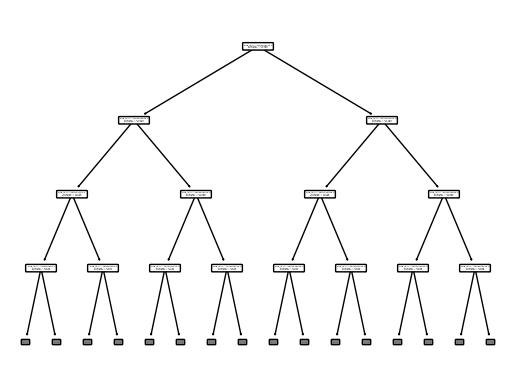

In [19]:
from sklearn.tree import DecisionTreeClassifier , plot_tree

decision_tree_classification = DecisionTreeClassifier(criterion='entropy', random_state=10)
decision_tree = decision_tree_classification.fit(x_train,y_train)

plot_tree(decision_tree, max_depth=3, feature_names = x_train.columns,rounded=True)
plt.show()

In [20]:
y_pred_test = decision_tree.predict(x_test)
y_pred_train = decision_tree.predict(x_train)
print(decision_tree)

DecisionTreeClassifier(criterion='entropy', random_state=10)


In [22]:
from sklearn.metrics import classification_report

print(classification_report (y_train,y_pred_train))

/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

      568657       1.00      1.00      1.00         2
      582999       1.00      1.00      1.00         7
      642382       1.00      1.00      1.00         2
      751790       1.00      1.00      1.00         1
      778705       1.00      1.00      1.00         1
     1629671       1.00      1.00      1.00        11
     2061593       1.00      1.00      1.00         1
     2078097       1.00      1.00      1.00         1
     2366870       1.00      1.00      1.00         5
     2482631       1.00      1.00      1.00         4
     2521897       1.00      1.00      1.00         2
     3108700       1.00      1.00      1.00         1
     3851658       1.00      1.00      1.00         1
     3907459       1.00      1.00      1.00         4
     4431217       1.00      1.00      1.00         3
     4454049       1.00      1.00      1.00         8
     4559645       1.00      1.00      1.00         1
     4904504       1.00    

/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [24]:
print(len(y_train),(y_pred_train))

74760 [2646369602  323444694 3958067958 ... 4035691219 3239728398 1470287332]


In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100,random_state=42)
model.fit(x_train,y_train)

/tmp/ipykernel_33/1408708486.py:4: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  model.fit(x_train,y_train)


In [ ]:
y_pred = model.predict(x_test)
print(classification_report(y_test,y_pred))